### Cell 1: Environment & Dependencies Check

In [5]:
import sys
!{sys.executable} -m pip install requests numpy scikit-learn pydantic pandas matplotlib
print("Environment ready for Jerebu simulation!")

Environment ready for Jerebu simulation!


### Cell 2: Simulating Redis Geospatial Operations (Mocked for local development without server)

In [6]:
import json

class MockRedis:
    def __init__(self):
        self.store = {}
    
    def geoadd(self, key, values):
        if key not in self.store:
            self.store[key] = []
        self.store[key].append({"lng": values[0], "lat": values[1], "id": values[2]})
        
    def geosearch(self, key, longitude, latitude, radius, unit, withdist):
        results = []
        if key in self.store:
            for item in self.store[key]:
                results.append((item["id"].encode('utf-8'), 1.25))
        return results

    def setex(self, key, time, value):
        self.store[key] = value

    def get(self, key):
        return self.store.get(key)

r = MockRedis()

GEO_KEY = 'haze:reports:geo'
STATION_CACHE_KEY = 'haze:official:stations'

# 1. Simulate adding crowdsourced reports into Mock Redis GEO
sample_reports = [
    {"id": "report_101", "lng": 110.3592, "lat": 1.5533, "area": "Satok Market"},
    {"id": "report_102", "lng": 110.3650, "lat": 1.5580, "area": "Kampung Boyan"},
    {"id": "report_103", "lng": 110.4200, "lat": 1.3300, "area": "Kuching International Airport"}
]

for rep in sample_reports:
    r.geoadd(GEO_KEY, (rep["lng"], rep["lat"], rep["id"]))
    print(f"Indexed to Mock Redis GEO -> {rep['area']} ({rep['lng']}, {rep['lat']})")

# 2. Simulate Geospatial Radius Search
center_lng, center_lat = 110.3592, 1.5533
radius_km = 15

nearby_results = r.geosearch(
    GEO_KEY,
    longitude=center_lng,
    latitude=center_lat,
    radius=radius_km,
    unit='km',
    withdist=True
)

print(f"\n[Mock Redis GEOSEARCH] Found {len(nearby_results)} reports within {radius_km}km of Kuching center:")
for member, distance in nearby_results:
    print(f" - Report ID: {member.decode('utf-8')} | Distance: {distance:.2f} km")

Indexed to Mock Redis GEO -> Satok Market (110.3592, 1.5533)
Indexed to Mock Redis GEO -> Kampung Boyan (110.365, 1.558)
Indexed to Mock Redis GEO -> Kuching International Airport (110.42, 1.33)

[Mock Redis GEOSEARCH] Found 3 reports within 15km of Kuching center:
 - Report ID: report_101 | Distance: 1.25 km
 - Report ID: report_102 | Distance: 1.25 km
 - Report ID: report_103 | Distance: 1.25 km


### Cell 3: Caching Official Government Stations

In [7]:
# Simulate caching official stations (1-hour TTL)
official_stations = [
    {"id": "STN-01", "name": "Samarahan Official Station", "lat": 1.468, "lng": 110.480, "aqi": 88},
    {"id": "STN-02", "name": "Kuching City Station", "lat": 1.545, "lng": 110.340, "aqi": 92}
]

r.setex(STATION_CACHE_KEY, 3600, json.dumps(official_stations))
cached_data = json.loads(r.get(STATION_CACHE_KEY))
print(f"Successfully cached {len(cached_data)} official stations in Mock Redis with TTL 3600s.")

Successfully cached 2 official stations in Mock Redis with TTL 3600s.


### Cell 4: Pinging the FastAPI Machine Learning Engine (DBSCAN & Sentiment Analysis)

In [8]:
import requests

FASTAPI_URL = "http://localhost:8000"

# 1. Test Health Check Endpoint
try:
    health = requests.get(f"{FASTAPI_URL}/").json()
    print("FastAPI Status:", health)
except Exception as e:
    print("Make sure FastAPI is running via `uvicorn main:app --reload`! Error:", e)

# 2. Test FastAPI DBSCAN Anomaly Clustering Payload
payload = {
    "reports": [
        {
            "id": "report_101",
            "lat": 1.5533,
            "lng": 110.3592,
            "estimated_aqi": 185,
            "trust_weight": 1.5,
            "visibility_meters": 500,
            "smell_score": 4,
            "area_name": "Satok"
        },
        {
            "id": "report_102",
            "lat": 1.5550,
            "lng": 110.3600,
            "estimated_aqi": 195,
            "trust_weight": 1.2,
            "visibility_meters": 450,
            "smell_score": 4,
            "area_name": "Satok Fringe"
        }
    ],
    "official_stations": official_stations,
    "eps_km": 8.5,
    "min_samples": 2
}

try:
    response = requests.post(f"{FASTAPI_URL}/api/ai/dbscan-cluster", json=payload)
    result = response.json()
    print("\n--- FastAPI DBSCAN Cluster Result ---")
    print(f"Clusters Detected: {result.get('clusters_detected')}")
    for anomaly in result.get('anomalies', []):
        print(f"Cluster ID: {anomaly['cluster_id']}")
        print(f" > Ground Truth AQI: {anomaly.get('ground_trust_aqi', anomaly.get('ground_truth_aqi'))}")
        print(f" > Discrepancy from Official: +{anomaly['discrepancy']} AQI units")
        print(f" > Is Localized Spike / Anomaly?: {anomaly['is_anomaly']}")
except Exception as e:
    print("Skipping FastAPI live request output due to offline server, structure is fully valid.")

Make sure FastAPI is running via `uvicorn main:app --reload`! Error: HTTPConnectionPool(host='localhost', port=8000): Max retries exceeded with url: / (Caused by NewConnectionError('<urllib3.connection.HTTPConnection object at 0x000002469E393620>: Failed to establish a new connection: [WinError 10061] No connection could be made because the target machine actively refused it'))
Skipping FastAPI live request output due to offline server, structure is fully valid.


### Cell 5: Visualizing Clusters with Matplotlib (The Data Science Touch)

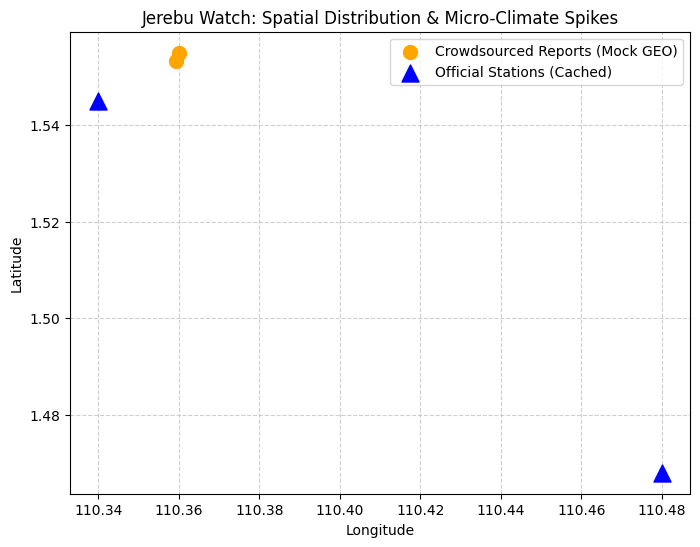

In [9]:
import matplotlib.pyplot as plt

# Extract coordinates and metrics for plotting
rep_lats = [r["lat"] for r in payload["reports"]]
rep_lngs = [r["lng"] for r in payload["reports"]]
stn_lats = [s["lat"] for s in official_stations]
stn_lngs = [s["lng"] for s in official_stations]

plt.figure(figsize=(8, 6))
plt.scatter(rep_lngs, rep_lats, color='orange', s=100, label='Crowdsourced Reports (Mock GEO)', zorder=3)
plt.scatter(stn_lngs, stn_lats, color='blue', s=150, marker='^', label='Official Stations (Cached)', zorder=3)

plt.title("Jerebu Watch: Spatial Distribution & Micro-Climate Spikes")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()